### Import and Connect

In [29]:
import duckdb
conn = duckdb.connect('algory.duckdb')

def load_table(name):
    return conn.sql(f"SELECT * FROM {name}").df()

##### Trades

In [30]:
trades = load_table("trades")
display(trades)

,trade_id,timestamp,strategy,symbol,side,quantity,price
0,1763913383618496,2025-11-23 10:56:23.618496,cluster_v2,MSFT,BUY,0.389841,97.118374
1,1763913383913346,2025-11-23 10:56:23.913346,pairs,NVDA,BUY,30.928146,238.337223
2,1763913384913482,2025-11-23 10:56:24.913482,momentum,GOOG,BUY,28.206942,177.261325
3,1763913385977734,2025-11-23 10:56:25.977734,mean_reversion,AAPL,BUY,5.000000,227.834405
4,1763913385977734,2025-11-23 10:56:25.977734,mean_reversion,AMZN,BUY,5.000000,266.157023
...,...,...,...,...,...,...,...
292,1763913478622357,2025-11-23 10:57:58.622357,mean_reversion,JPM,BUY,5.000000,181.959891
293,1763913478622357,2025-11-23 10:57:58.622357,mean_reversion,XOM,BUY,5.000000,73.856398
294,1763913478622357,2025-11-23 10:57:58.622357,mean_reversion,NFLX,SELL,-5.000000,156.638120
295,1763913478622357,2025-11-23 10:57:58.622357,mean_reversion,WMT,BUY,5.000000,42.180472


##### Portfolio History

In [31]:
portfolio_history = load_table("portfolio_history")
display(portfolio_history)

,timestamp,total_value,total_cash,total_positions
0,2025-11-23 10:56:25.977734,99764.870064,82654.453950,9
1,2025-11-23 10:56:28.380221,99762.565227,80387.929677,9
2,2025-11-23 10:56:30.978702,99272.285300,70312.820561,10
3,2025-11-23 10:56:32.805920,99411.186263,65312.820561,10
4,2025-11-23 10:56:35.580538,99417.704300,55269.689927,12
5,2025-11-23 10:56:37.574896,99897.799749,51114.597655,12
6,2025-11-23 10:56:39.965302,100522.607254,48252.033876,12
7,2025-11-23 10:56:42.322562,100063.174604,40945.861952,12
8,2025-11-23 10:56:44.572636,99806.638653,42043.331362,12
9,2025-11-23 10:56:47.055937,100822.776606,38221.618421,12


##### Strategy History

In [32]:
strategy_history = load_table("strategy_history")
display(strategy_history)

,timestamp,strategy,strategy_value,cash,exposure,n_positions
0,2025-11-23 10:56:25.977734,cluster_v2,24999.518565,24962.139286,37.379279,1
1,2025-11-23 10:56:25.977734,mean_reversion,25000.000000,20063.642981,4936.357019,7
2,2025-11-23 10:56:25.977734,momentum,24948.733237,20000.000000,4948.733237,1
3,2025-11-23 10:56:25.977734,pairs,24816.618261,17628.671682,7187.946579,1
4,2025-11-23 10:56:28.380221,cluster_v2,24999.821125,24962.139286,37.681839,1
...,...,...,...,...,...,...
159,2025-11-23 10:57:56.139440,pairs,23546.371588,-29765.114577,53311.486165,9
160,2025-11-23 10:57:58.622357,cluster_v2,25174.953056,18769.553918,6405.399138,8
161,2025-11-23 10:57:58.622357,mean_reversion,27524.584065,27754.823118,-230.239054,10
162,2025-11-23 10:57:58.622357,momentum,24455.601621,-33958.716020,58414.317640,12


### Plot value over time

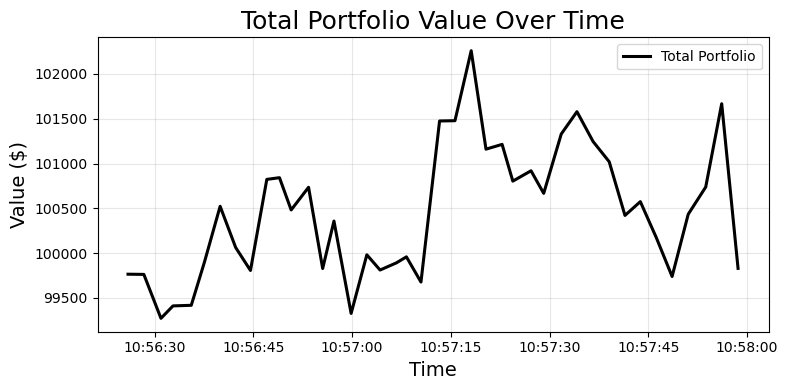

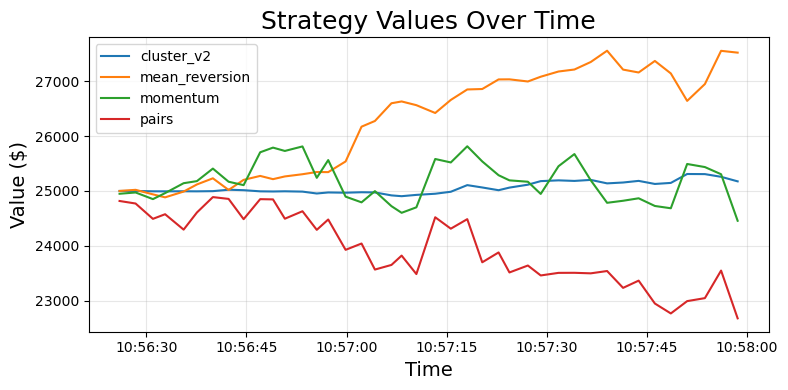

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_portfolio(portfolio: pd.DataFrame):
    plt.figure(figsize=(8, 4))

    plt.plot(
        pd.to_datetime(portfolio["timestamp"]),
        portfolio["total_value"],
        color="black",
        linewidth=2.2,
        label="Total Portfolio"
    )

    plt.title("Total Portfolio Value Over Time", fontsize=18)
    plt.xlabel("Time", fontsize=14)
    plt.ylabel("Value ($)", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_strategies(strategies: pd.DataFrame):
    plt.figure(figsize=(8, 4))

    for strat, df in strategies.groupby("strategy"):
        plt.plot(
            pd.to_datetime(df["timestamp"]),
            df["strategy_value"],
            label=strat  # auto-colored
        )

    plt.title("Strategy Values Over Time", fontsize=18)
    plt.xlabel("Time", fontsize=14)
    plt.ylabel("Value ($)", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_portfolio(portfolio_history)
plot_strategies(strategy_history)

### View portfolio metrics

In [34]:
from stats import getStats
import pandas as pd

##### Portfolio Stats

In [35]:
portfolio_stats = getStats.compute_portfolio_metrics(portfolio_history)
series = pd.Series(portfolio_stats)
display(series)

PnL                           6.487110e-04
Absolute PnL                  6.471857e+01
CAGR                          8.616158e+95
Max Drawdown                 -2.463735e-02
Sharpe Ratio                  2.089774e+01
Sortino Ratio                 2.017327e+01
Volatility                    2.393189e+01
Value at Risk (95%)          -1.029521e-02
Beta to Market                         NaN
Kurtosis                      1.455185e+00
Average Trade Return          3.670779e-05
Median Trade Return           1.271454e-04
Win/Loss Ratio                1.222222e+00
Average Win / Average Loss    8.308879e-01
dtype: float64

##### Strategy Stats

In [36]:
strategy_stats = getStats.compute_strategy_metrics(strategy_history)
df = pd.DataFrame(strategy_stats)
display(df)

/Users/ryanvandeberghe/Documents/infrastructure/src/stats/getStats.py:195: RuntimeWarning: overflow encountered in scalar power
  cagr = (end_val / start_val) ** (1 / years) - 1
/Users/ryanvandeberghe/Documents/infrastructure/src/stats/getStats.py:195: RuntimeWarning: overflow encountered in scalar power
  cagr = (end_val / start_val) ** (1 / years) - 1


,cluster_v2,mean_reversion,momentum,pairs
PnL,0.007018,0.100983,-0.019766,-0.086320
Absolute PnL,175.434491,2524.584065,-493.131616,-2142.168370
CAGR,inf,inf,-1.000000,-1.000000
Max Drawdown,-0.005304,-0.033240,-0.052661,-0.088929
Sharpe Ratio,358.794477,1140.665001,-107.448371,-535.881206
Sortino Ratio,455.615546,1225.216797,-117.178617,-486.833921
Volatility,6.700394,29.124462,51.341762,54.605287
Value at Risk (95%),-0.002239,-0.008615,-0.022398,-0.023096
Beta to Market,NaN,NaN,NaN,NaN
Kurtosis,3.437656,2.249625,1.238183,1.711976


### Close DB

In [37]:
conn.close()